### Importing required data sources & Viewing data

In [49]:
# ECB API data
import os
import certifi
import requests
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from io import StringIO # Will turn the string to a file like object

# Fix my SSL certificate issue
os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()

# ECB URL - Coming from the European Central Bank (ECB) Data Warehouse / Data Portal API.
url = "https://data-api.ecb.europa.eu/service/data/FM/B.U2.EUR.4F.KR.DFR.LEV?format=csvdata"

# Getting data from ECB
response = requests.get(url)
response.raise_for_status()

# Turn the text 'response' into a DataFrame
df_ecb = pd.read_csv(StringIO(response.text)) # Moves data to pandas

In [50]:
df_ecb.shape

(67, 40)

In [51]:
print(df_ecb.head())

                         KEY FREQ REF_AREA CURRENCY PROVIDER_FM INSTRUMENT_FM  \
0  FM.B.U2.EUR.4F.KR.DFR.LEV    B       U2      EUR          4F            KR   
1  FM.B.U2.EUR.4F.KR.DFR.LEV    B       U2      EUR          4F            KR   
2  FM.B.U2.EUR.4F.KR.DFR.LEV    B       U2      EUR          4F            KR   
3  FM.B.U2.EUR.4F.KR.DFR.LEV    B       U2      EUR          4F            KR   
4  FM.B.U2.EUR.4F.KR.DFR.LEV    B       U2      EUR          4F            KR   

  PROVIDER_FM_ID DATA_TYPE_FM TIME_PERIOD  OBS_VALUE  ... UNIT_INDEX_BASE  \
0            DFR          LEV  1999-01-01       2.00  ...             NaN   
1            DFR          LEV  1999-01-04       2.75  ...             NaN   
2            DFR          LEV  1999-01-22       2.00  ...             NaN   
3            DFR          LEV  1999-04-09       1.50  ...             NaN   
4            DFR          LEV  1999-11-05       2.00  ...             NaN   

  COMPILATION  COVERAGE  DECIMALS SOURCE_AGENCY  S

In [52]:
print(df_ecb.columns)

Index(['KEY', 'FREQ', 'REF_AREA', 'CURRENCY', 'PROVIDER_FM', 'INSTRUMENT_FM',
       'PROVIDER_FM_ID', 'DATA_TYPE_FM', 'TIME_PERIOD', 'OBS_VALUE',
       'OBS_STATUS', 'OBS_CONF', 'OBS_PRE_BREAK', 'OBS_COM', 'TIME_FORMAT',
       'BREAKS', 'COLLECTION', 'COMPILING_ORG', 'DISS_ORG', 'DOM_SER_IDS',
       'FM_CONTRACT_TIME', 'FM_COUPON_RATE', 'FM_IDENTIFIER', 'FM_LOT_SIZE',
       'FM_MATURITY', 'FM_OUTS_AMOUNT', 'FM_PUT_CALL', 'FM_STRIKE_PRICE',
       'PUBL_MU', 'PUBL_PUBLIC', 'UNIT_INDEX_BASE', 'COMPILATION', 'COVERAGE',
       'DECIMALS', 'SOURCE_AGENCY', 'SOURCE_PUB', 'TITLE', 'TITLE_COMPL',
       'UNIT', 'UNIT_MULT'],
      dtype='object')


In [53]:
df_ecb.isnull().sum()

KEY                  0
FREQ                 0
REF_AREA             0
CURRENCY             0
PROVIDER_FM          0
INSTRUMENT_FM        0
PROVIDER_FM_ID       0
DATA_TYPE_FM         0
TIME_PERIOD          0
OBS_VALUE            0
OBS_STATUS           0
OBS_CONF             0
OBS_PRE_BREAK       67
OBS_COM             67
TIME_FORMAT          0
BREAKS              67
COLLECTION           0
COMPILING_ORG       67
DISS_ORG            67
DOM_SER_IDS         67
FM_CONTRACT_TIME    67
FM_COUPON_RATE      67
FM_IDENTIFIER       67
FM_LOT_SIZE         67
FM_MATURITY         67
FM_OUTS_AMOUNT      67
FM_PUT_CALL         67
FM_STRIKE_PRICE     67
PUBL_MU             67
PUBL_PUBLIC         67
UNIT_INDEX_BASE     67
COMPILATION         67
COVERAGE            67
DECIMALS             0
SOURCE_AGENCY       67
SOURCE_PUB          67
TITLE                0
TITLE_COMPL          0
UNIT                 0
UNIT_MULT            0
dtype: int64

In [54]:
df_ecb.describe()

,OBS_VALUE,OBS_PRE_BREAK,OBS_COM,BREAKS,COMPILING_ORG,DISS_ORG,DOM_SER_IDS,FM_CONTRACT_TIME,FM_COUPON_RATE,FM_IDENTIFIER,...,FM_STRIKE_PRICE,PUBL_MU,PUBL_PUBLIC,UNIT_INDEX_BASE,COMPILATION,COVERAGE,DECIMALS,SOURCE_AGENCY,SOURCE_PUB,UNIT_MULT
count,67.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,67.0,0.0,0.0,67.0
mean,1.962687,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,0.0
std,1.279688,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0
min,-0.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,0.0
25%,0.875000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,0.0
50%,2.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,0.0
75%,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,0.0
max,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,0.0


In [55]:
df_ecb['OBS_VALUE']

0     2.00
1     2.75
2     2.00
3     1.50
4     2.00
      ... 
62    3.00
63    2.75
64    2.50
65    2.25
66    2.00
Name: OBS_VALUE, Length: 67, dtype: float64

In [56]:
df_ecb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 40 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   KEY               67 non-null     object 
 1   FREQ              67 non-null     object 
 2   REF_AREA          67 non-null     object 
 3   CURRENCY          67 non-null     object 
 4   PROVIDER_FM       67 non-null     object 
 5   INSTRUMENT_FM     67 non-null     object 
 6   PROVIDER_FM_ID    67 non-null     object 
 7   DATA_TYPE_FM      67 non-null     object 
 8   TIME_PERIOD       67 non-null     object 
 9   OBS_VALUE         67 non-null     float64
 10  OBS_STATUS        67 non-null     object 
 11  OBS_CONF          67 non-null     object 
 12  OBS_PRE_BREAK     0 non-null      float64
 13  OBS_COM           0 non-null      float64
 14  TIME_FORMAT       67 non-null     object 
 15  BREAKS            0 non-null      float64
 16  COLLECTION        67 non-null     object 
 17 

In [57]:
df_ecb['OBS_VALUE'].dtypes

dtype('float64')

In [58]:
df_ecb['TIME_PERIOD'].dtypes

dtype('O')

In [59]:
df_ecb['TIME_PERIOD']

0     1999-01-01
1     1999-01-04
2     1999-01-22
3     1999-04-09
4     1999-11-05
         ...    
62    2024-12-18
63    2025-02-05
64    2025-03-12
65    2025-04-23
66    2025-06-11
Name: TIME_PERIOD, Length: 67, dtype: object

In [60]:
df_ecb['TIME_PERIOD'].min()

'1999-01-01'

## Data Wrangling

In [61]:
# Keeping dates only 2015 onwards
df_ecb = df_ecb[df_ecb['TIME_PERIOD'] >= '2015-01-01']

In [62]:
# Chaning date format
df_ecb['TIME_PERIOD'] = pd.to_datetime(df_ecb['TIME_PERIOD']).dt.strftime('%Y-%m')
df_ecb['TIME_PERIOD'].values

array(['2015-12', '2016-03', '2019-09', '2022-07', '2022-09', '2022-11',
       '2022-12', '2023-02', '2023-03', '2023-05', '2023-06', '2023-08',
       '2023-09', '2024-06', '2024-09', '2024-10', '2024-12', '2025-02',
       '2025-03', '2025-04', '2025-06'], dtype=object)

In [63]:
# Removing everything expect the data and 'OBS_VALUE'
df_ecb = df_ecb[[ "TIME_PERIOD", "OBS_VALUE"]]

df_ecb = df_ecb.rename(columns={"TIME_PERIOD": "date","OBS_VALUE": "interest_rate"})

In [64]:
df_ecb.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21 entries, 46 to 66
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           21 non-null     object 
 1   interest_rate  21 non-null     float64
dtypes: float64(1), object(1)
memory usage: 504.0+ bytes


In [68]:
df_ecb.isnull().sum()

date             0
interest_rate    0
dtype: int64

In [67]:
df_ecb.head()

,date,interest_rate
46,2015-12,-0.30
47,2016-03,-0.40
48,2019-09,-0.50
49,2022-07,0.00
50,2022-09,0.75


####  Visualization for ECB & what it shows 

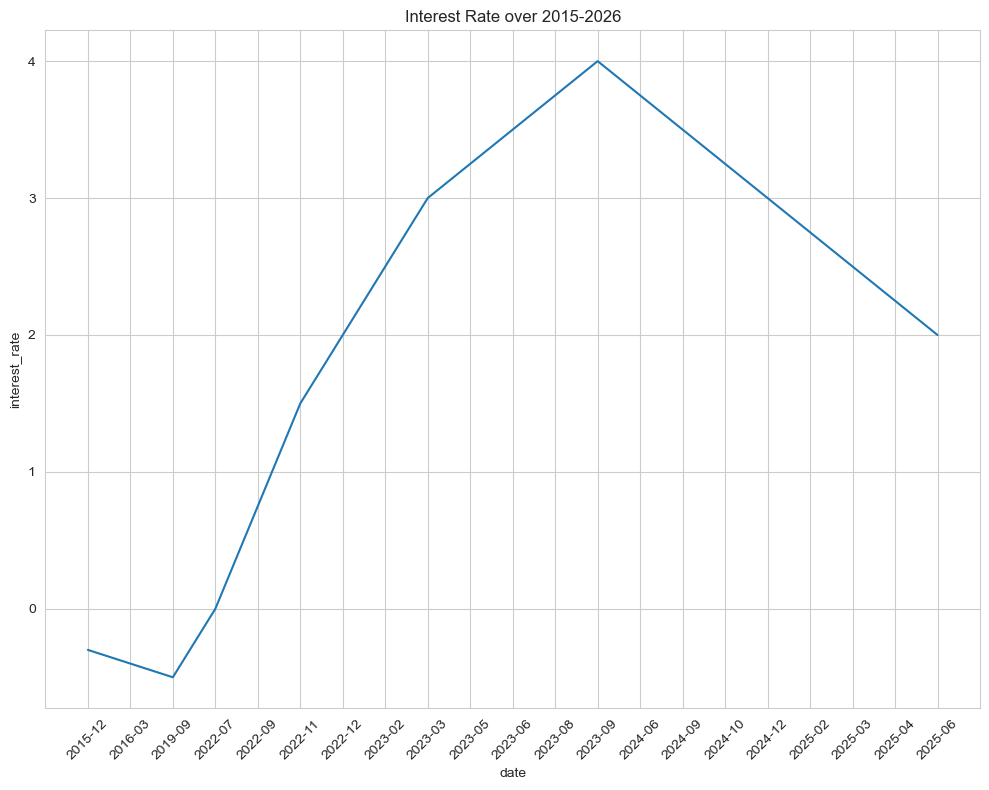

In [ ]:
sns.set_style('whitegrid')
plt.figure(figsize=(10,8))
sns.lineplot(data=df_ecb, x='date', y='interest_rate')

plt.xticks(rotation=45)
plt.title('Interest Rate from 2015-2025')
plt.tight_layout()
plt.show()

##### What this graph shows - 
#### Interest rates rise sharply (2022–2023) -- this is a reaction to inflation
